### [Time Series Analysis of Netflix Stocks](https://blog.stackademic.com/time-series-analysis-of-netflix-stocks-with-pandas-3ad8637b778c)

> Aim to introduce the concept of time series analysis and highlight its significance in various fields and presenting real-world examples that showcase the practical applications of time series analysis.

> Provide a practical demonstration by showcasing how to import Netflix stock data using Python and yfinance library. So that the readers will learn the necessary steps to acquire time series data and prepare it for analysis.

> Focus on important pandas functions used in time series analysis, such as shifting, rolling, and resampling which enables to manipulate and analyze time series data effectively.


_A time series is a sequence of data points collected or recorded over successive and equally spaced intervals of time._

- Time series analysis is a statistical technique for analyzing data points collected over time.
- It involves studying patterns, trends, and dependencies in sequential data to extract insights and make predictions.
- It involves techniques such as data visualization, statistical modeling, and forecasting methods to analyze and interpret time series data effectively.

In [1]:
!pip install -qU yfinance

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from datetime import datetime

In [3]:
df = yf.download(tickers = "NFLX", start='2002-01-01', end='2025-10-04')
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX
Date,,,,,
2002-05-23,1.196429,1.242857,1.145714,1.156429,104790000
2002-05-24,1.210000,1.225000,1.197143,1.214286,11104800
2002-05-28,1.157143,1.232143,1.157143,1.213571,6609400
2002-05-29,1.103571,1.164286,1.085714,1.164286,6757800
2002-05-30,1.071429,1.107857,1.071429,1.107857,10154200
...,...,...,...,...,...
2025-09-29,1206.410034,1224.489990,1187.540039,1205.000000,3033200
2025-09-30,1198.920044,1208.500000,1178.000000,1206.410034,3830300


In [4]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX
count,5880.000000,5880.000000,5880.000000,5880.000000,5.880000e+03
mean,186.755272,189.378547,183.944672,186.685678,1.499475e+07
std,262.551954,265.768698,258.998697,262.436338,1.830196e+07
min,0.372857,0.410714,0.346429,0.377857,2.856000e+05
25%,4.373929,4.453572,4.262143,4.339286,5.307925e+06
50%,48.688572,49.481430,47.748569,48.697859,9.235200e+06
75%,327.510002,332.169998,322.197495,327.662491,1.794012e+07
max,1339.130005,1341.150024,1321.209961,1338.229980,3.234140e+08


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5880 entries, 2002-05-23 to 2025-10-03
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NFLX)   5880 non-null   float64
 1   (High, NFLX)    5880 non-null   float64
 2   (Low, NFLX)     5880 non-null   float64
 3   (Open, NFLX)    5880 non-null   float64
 4   (Volume, NFLX)  5880 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 275.6 KB


In [6]:
df.shape

(5880, 5)

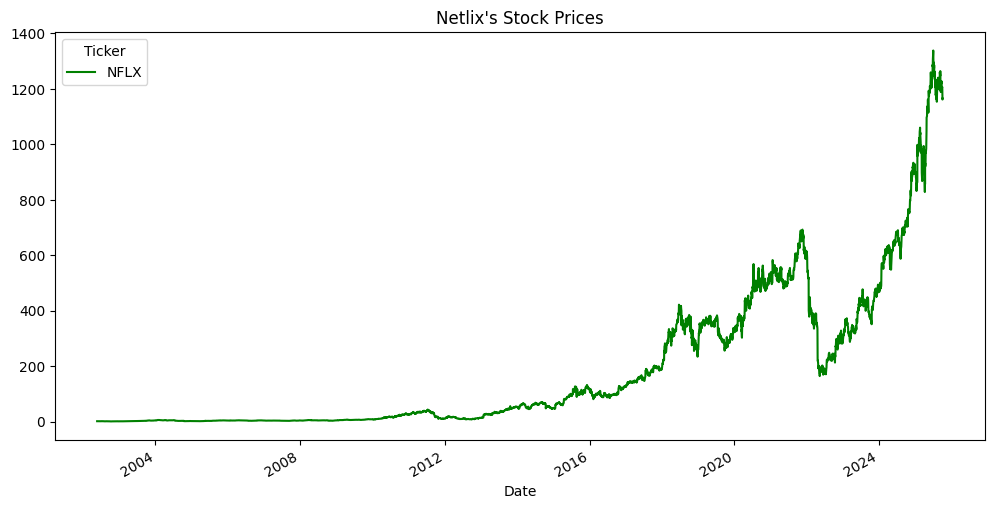

In [7]:
df['Open'].plot(figsize=(12,6),c='g')
plt.title("Netlix's Stock Prices")
plt.show()

In [8]:
df.shift(1)

Price,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX
Date,,,,,
2002-05-23,NaN,NaN,NaN,NaN,NaN
2002-05-24,1.196429,1.242857,1.145714,1.156429,104790000.0
2002-05-28,1.210000,1.225000,1.197143,1.214286,11104800.0
2002-05-29,1.157143,1.232143,1.157143,1.213571,6609400.0
2002-05-30,1.103571,1.164286,1.085714,1.164286,6757800.0
...,...,...,...,...,...
2025-09-29,1210.609985,1214.000000,1200.000000,1205.420044,1945000.0
2025-09-30,1206.410034,1224.489990,1187.540039,1205.000000,3033200.0


In [9]:
df.shift(-1)

Price,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX
Date,,,,,
2002-05-23,1.210000,1.225000,1.197143,1.214286,11104800.0
2002-05-24,1.157143,1.232143,1.157143,1.213571,6609400.0
2002-05-28,1.103571,1.164286,1.085714,1.164286,6757800.0
2002-05-29,1.071429,1.107857,1.071429,1.107857,10154200.0
2002-05-30,1.076429,1.078571,1.071429,1.078571,8464400.0
...,...,...,...,...,...
2025-09-29,1198.920044,1208.500000,1178.000000,1206.410034,3830300.0
2025-09-30,1170.900024,1179.140015,1163.209961,1175.489990,4110200.0


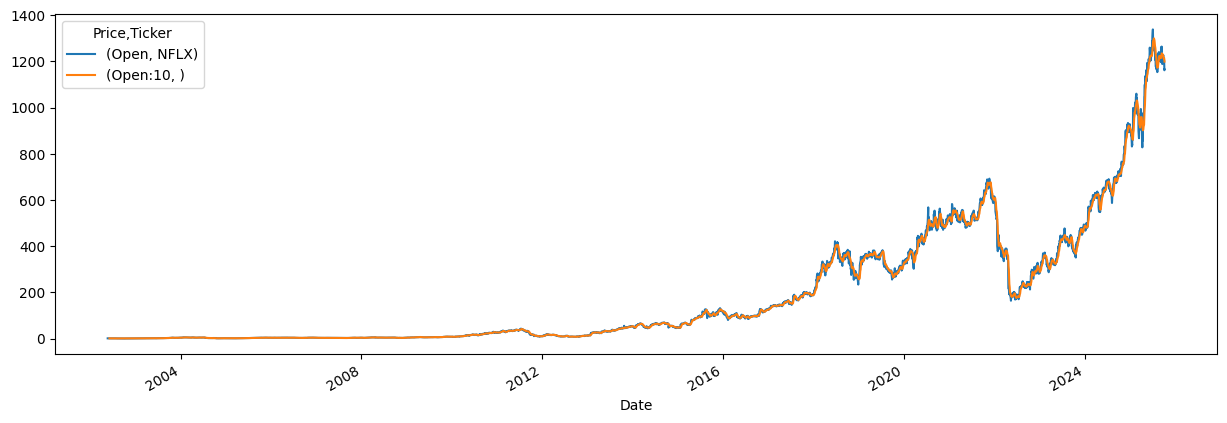

In [10]:
df['Open:10'] = df['Open'].rolling(10).mean()
df[['Open','Open:10']].head(20)
df[['Open','Open:10']].plot(figsize=(15,5))
plt.show()

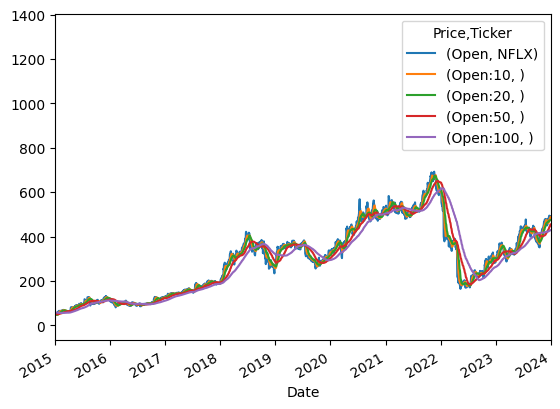

In [11]:
df['Open:20'] = df['Open'].rolling(window=20,min_periods=1).mean()
df['Open:50'] = df['Open'].rolling(window=50,min_periods=1).mean()
df['Open:100'] = df['Open'].rolling(window=100,min_periods=1).mean()
#visualization
df[['Open','Open:10','Open:20','Open:50','Open:100']].plot(xlim=['2015-01-01','2024-01-01'])
plt.show()

In [12]:
df.resample(rule='A').max()

Price,Close,High,Low,Open,Volume,Open:10,Open:20,Open:50,Open:100
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX,,,,
Date,,,,,,,,,
2002-12-31,1.276429,1.299286,1.213571,1.278571,104790000,1.195500,1.194762,1.194762,1.194762
2003-12-31,4.257143,4.357143,4.147143,4.310000,125825000,4.038286,3.821321,3.634129,3.072300
2004-12-31,5.547143,5.681429,5.460714,5.535714,323414000,5.302429,5.265821,4.855157,4.660814
2005-12-31,4.295714,4.321429,4.191429,4.300000,149679600,4.124714,4.052643,3.936143,3.656443
2006-12-31,4.525714,4.731429,4.457143,4.715714,106622600,4.414429,4.355286,4.166857,3.982000
2007-12-31,4.100000,4.162857,3.958571,4.014286,64801800,3.809572,3.927572,3.993429,3.649371
2008-12-31,5.814286,5.842857,5.508571,5.818571,73231900,5.327571,5.283357,4.899514,4.593900
2009-12-31,8.732857,8.807143,8.605714,8.687143,60159400,8.523143,8.382786,8.033143,7.249443


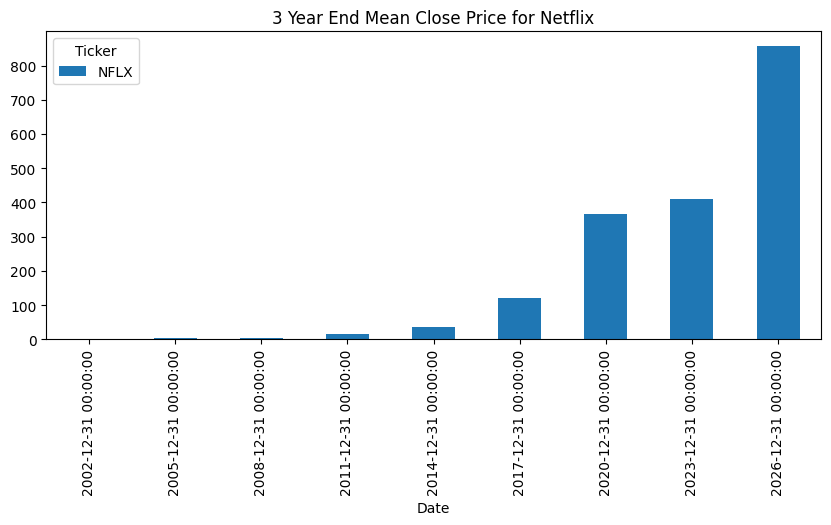

In [14]:
df['Close'].resample(rule='3Y').mean().plot(kind='bar',figsize=(10,4))
plt.title('3 Year End Mean Close Price for Netflix')
plt.show()